In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
import scienceplots
from os.path import exists
import seaborn as sns


from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

SPEED_OF_LIGHT = 299_792.458
paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

In [2]:
from csiborgtools import radec_to_galactic
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.3)


with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR.hdf5", 'r') as f:
    dtype = [(key, np.float32) for key in f.keys()]
    dtype += [("DEC", np.float32)]
    arr = np.empty(len(f["RA"]), dtype=dtype)

    for key in f.keys():
        arr[key] = f[key][:]
    arr["DEC"] = arr["DE"]
    arr["RA"] *= 360 / 24

band = "w1"
zcmb_max = 0.05001
zcmb_min = 0.0
if band not in ['g', 'r', 'i', 'z', 'w1', 'w2']:
    raise ValueError(f"Band `{band}` not recognized.")



keys = ["RA", "DEC", "Vcmb", f"{band}", "lgWmxi", "elgWi", "Qs", "Qw",
        "inc_e"]
RA, dec, z_obs, mag, eta, e_eta, Qs, Qw, e_inc = (arr[k] for k in keys)
l, b = radec_to_galactic(RA, dec)

# NOTE: fiducial uncertainty until we can get the actual values.
e_mag = 0.05 * np.ones_like(mag)

z_obs /= SPEED_OF_LIGHT
eta -= 2.5

print("selecting only galaxies with mag > 5 and eta > -0.3.")
mask = (mag > 5) & (eta > -0.3)
print("selecting only galaxies with |b| > 7.5.")
mask &= np.abs(b) > 7.5
mask &= (z_obs < zcmb_max) & (z_obs > zcmb_min)


print("employing a quality cut on the galaxies.")
if "w" in band:
    mask &= Qw == 5
else:
    mask &= Qs == 5

selecting only galaxies with mag > 5 and eta > -0.3.
selecting only galaxies with |b| > 7.5.
employing a quality cut on the galaxies.


In [3]:
from scipy.special import logsumexp

def read_ll_per_galaxy(simname, catalogue):
    fname = paths.flow_validation(
        fdir, simname, catalogue=catalogue, inference_method="mike",
        sample_alpha=True, sample_beta=None, zcmb_max=0.05001, verbose_print=False)

    with File(fname, "r") as f:
        ll = f[f"samples/ll_per_galaxy_{catalogue}_deterministic"][...]

    nsamples = ll.shape[0]
    return logsumexp(ll, axis=0) - np.log(nsamples)

In [4]:
sims = ["Carrick2015", "Lilow2024", "csiborg1", "csiborg2_main", "CLONES", "CF4"]
catalogue = "CF4_TFR_w1"

ll = {}
for simname in sims:
    ll[simname] = read_ll_per_galaxy(simname, catalogue)


In [5]:
xs = {
    "RA": arr["RA"][mask],
    "DEC": arr["DEC"][mask],
    "GLat": arr["GLat"][mask],
    "GLon": arr["GLong"][mask],
    "z_obs": z_obs[mask],
    "inc": arr["inc"][mask],
    "e_inc": arr["inc_e"][mask],
    "M": (mag - cosmo.distmod(z_obs).value)[mask],
    "mag": mag[mask],
    "eta": eta[mask],
    "e_eta": e_eta[mask],
}

In [6]:
from scipy.stats import spearmanr

dlogL = ll["csiborg2_main"] - ll["CF4"]

In [7]:
spearmanr(xs["eta"], dlogL)

SignificanceResult(statistic=0.18361049136425733, pvalue=3.024194366320807e-26)

RA (3278,) (3278,)
DEC (3278,) (3278,)
GLat (3278,) (3278,)
GLon (3278,) (3278,)
z_obs (3278,) (3278,)
inc (3278,) (3278,)
e_inc (3278,) (3278,)
M (3278,) (3278,)
mag (3278,) (3278,)
eta (3278,) (3278,)
e_eta (3278,) (3278,)


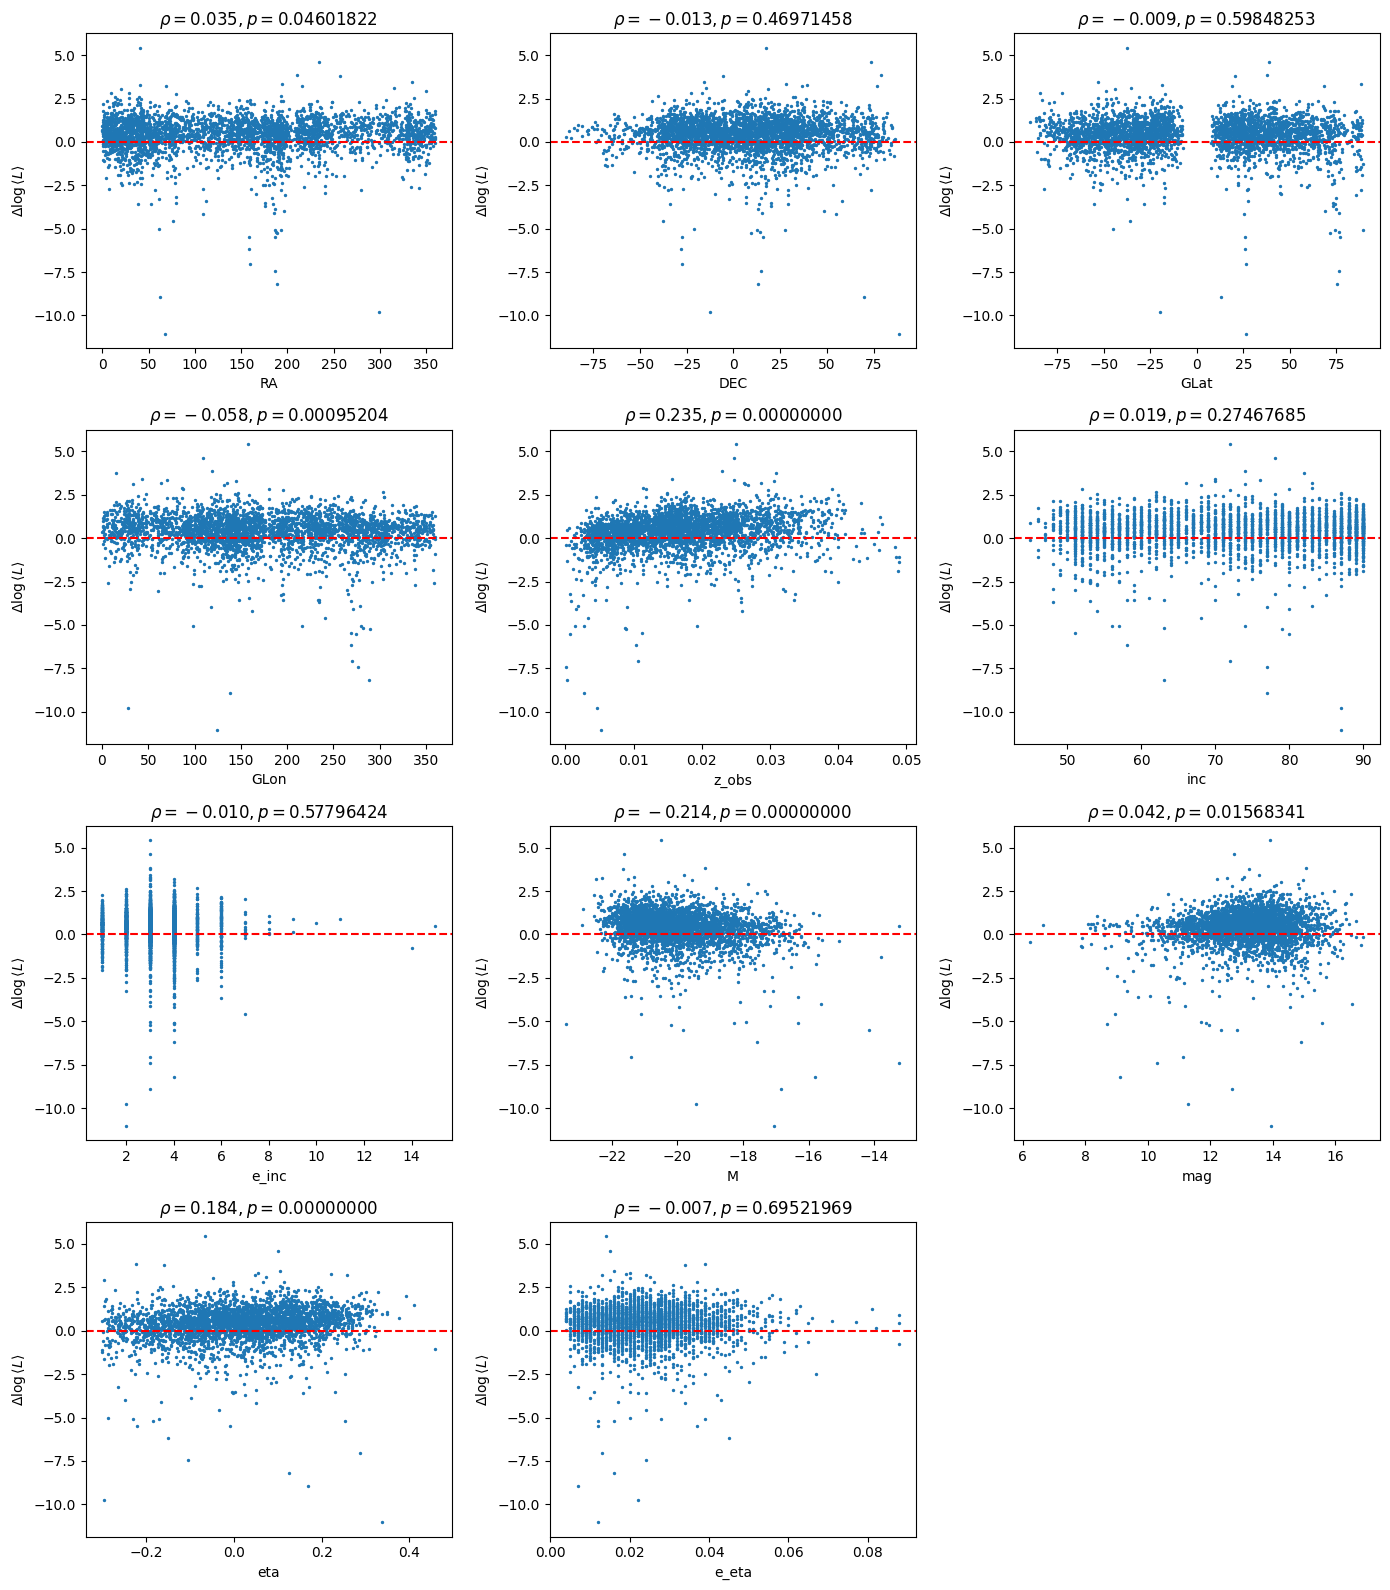

In [8]:
ncols = 3
nrows = (len(xs) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

# Loop through each dataset and plot in its own panel
for ax, (label, x) in zip(axes, xs.items()):
    print(label, x.shape, dlogL.shape)
    ax.scatter(x, dlogL, s=2, label=label)
    corr, p = spearmanr(x, dlogL)

    ax.set_title(rf"$\rho = {corr:.3f}, p = {p:.8f}$")
    ax.set_xlabel(label)
    ax.set_ylabel(r"$\Delta \log \langle L \rangle$")

    ax.axhline(0, color='red', linestyle='--')

# Hide any unused subplots
for ax in axes[len(xs):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("../../plots/dloGL_CB2_CB1.png", dpi=450)
plt.show()

In [9]:
xs["eta"].shape

(3278,)

In [13]:
xs.keys()

dict_keys(['RA', 'DEC', 'GLat', 'GLon', 'z_obs', 'inc', 'e_inc', 'M', 'mag', 'eta', 'e_eta'])

SignificanceResult(statistic=0.23474209501402685, pvalue=2.8217749068265553e-42)


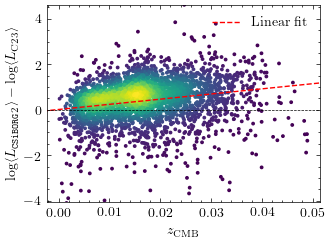

In [15]:
from scipy.stats import gaussian_kde

dlogL = ll["csiborg2_main"] - ll["CF4"]

with plt.style.context("science"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for spine_name, spine in ax.spines.items():
        col_spine = spine.get_edgecolor()
        lw_spine = spine.get_linewidth()

    # x, y = xs["eta"], dlogL
    x, y = xs["z_obs"], dlogL
    print(spearmanr(x, y))
    kde = gaussian_kde(np.vstack([x, y]))
    plt.scatter(x, y, s=3, c=kde(np.vstack([x, y])), cmap='viridis', rasterized=True)

    xlim = plt.xlim()

    ps = np.polyfit(x, y, 1)
    xrange = np.linspace(-5, 5, 100)
    plt.plot(xrange, np.polyval(ps, xrange), color='red', ls="--", lw=2 * lw_spine, label="Linear fit")


    plt.axhline(0, color=col_spine, linestyle='--', lw=lw_spine)

    plt.xlabel(r"$z_{\rm CMB}$")
    # plt.xlabel(r"$\eta$")
    plt.ylabel(r"$\log \langle L_{\texttt{CSiBORG}2} \rangle - \log \langle L_{\mathrm{C23}} \rangle$")

    plt.xlim(*xlim)
    plt.ylim(*np.percentile(y, [0.5, 99.97]))

    plt.legend()
    plt.tight_layout()
    # plt.savefig("../../plots/eta_vs_dlogL_CB2_CF4.pdf", dpi=450)
    plt.savefig("../../plots/zobs_vs_dlogL_CB2_CF4.pdf", dpi=450)

    plt.show()